Задание 1 (4 балла)

Выберать датасет из любого открытого источника, например: https://www.kaggle.com, https://dorozhnij.com/opendata, https://github.com/awesomedata/awesome-public-datasets?tab=readme-ov-file.

1.1 Анализ данных

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных для социологического исследования
df = pd.read_csv('putin_tucker.csv')

# Вывод названий столбцов для проверки структуры датасета
print("Доступные столбцы в датасете:")
print(df.columns.tolist())

# Отображение первых нескольких строк для визуального анализа
display(df.head())

Доступные столбцы в датасете:
['Comment', 'Anonymized Author', 'Published At', 'Likes', 'Reply Count']


,Comment,Anonymized Author,Published At,Likes,Reply Count
0,Watch my immediate reaction to the interview h...,533fb31af87a0ff551c4dc7a73634ccf7e9005f8eb4673...,2024-02-08T23:44:11Z,25601,750
1,The Russian to English translator did an EXCEL...,e00ef7ce570d1e6ba6e914755ffb9a0055386a3b0a6114...,2024-02-09T02:33:19Z,79514,750
2,The translation from Russian to English was ex...,c4add09939263f9b8509035f63b869662bc542641a3dc3...,2024-02-19T04:32:50Z,265,5
3,That was the longest 1 minute and 30 seconds h...,5b4d9b16bbfbc80edcb1941313fc0ee53748aea58bf3b8...,2024-02-18T06:58:59Z,1076,27
4,What's the difference between Tucker and a mob...,05ed0eddfa93d78083bcfb64186f749c6667c87da5ebc5...,2024-02-19T09:52:34Z,70,0


1.2 Ключевые метрики выборки

In [41]:
# Определяем метрики вовлеченности на основе доступных данных
# Создадим целевую переменную: 'High Engagement' (топ 25% по лайкам)
engagement_threshold = df['Likes'].quantile(0.75)
df['High_Engagement'] = (df['Likes'] > engagement_threshold).astype(int)

print(f"Общее количество проанализированных комментариев: {len(df)}")
print(f"Порог для высокой вовлеченности (лайки): {engagement_threshold}")
print(f"Доля высокорезонансных комментариев: {df['High_Engagement'].mean()*100:.1f}%")
print(f"Среднее количество лайков: {df['Likes'].mean():.1f}")
print(f"Среднее количество ответов: {df['Reply Count'].mean():.1f}")

Общее количество проанализированных комментариев: 100000
Порог для высокой вовлеченности (лайки): 11.0
Доля высокорезонансных комментариев: 24.1%
Среднее количество лайков: 52.2
Среднее количество ответов: 2.4


1.3 Предобработка и инженерия признаков

In [42]:
# Предобработка текстовых и временных данных
df['Published At'] = pd.to_datetime(df['Published At'])

# Инженерия признаков на основе метаданных комментария
df['Comment_Length'] = df['Comment'].str.len().fillna(0)
df['Hour_Published'] = df['Published At'].dt.hour
df['Day_of_Week'] = df['Published At'].dt.dayofweek
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

# Оценка 'авторитетности' через Reply Count
df['Reply_Ratio'] = df['Reply Count'] / (df['Likes'] + 1)

# Выбор признаков для социологического прогноза популярности
features = ['Comment_Length', 'Hour_Published', 'Day_of_Week', 'Is_Weekend', 'Reply Count']
X = df[features].fillna(0)
y = df['High_Engagement']

2. Провести аналитическое исследование по выбранному датасету;

2.1 Построение модели и оценка

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Исправленные метки для отчета классификации
print(classification_report(y_test, y_pred, target_names=['Низкая вовлеченность', 'Высокая вовлеченность']))
print(f"Accuracy: {model.score(X_test, y_test):.3f}")

                       precision    recall  f1-score   support

 Низкая вовлеченность       1.00      1.00      1.00     18984
Высокая вовлеченность       1.00      1.00      1.00      6016

             accuracy                           1.00     25000
            macro avg       1.00      1.00      1.00     25000
         weighted avg       1.00      1.00      1.00     25000

Accuracy: 0.999


2.2 Анализ важности признаков

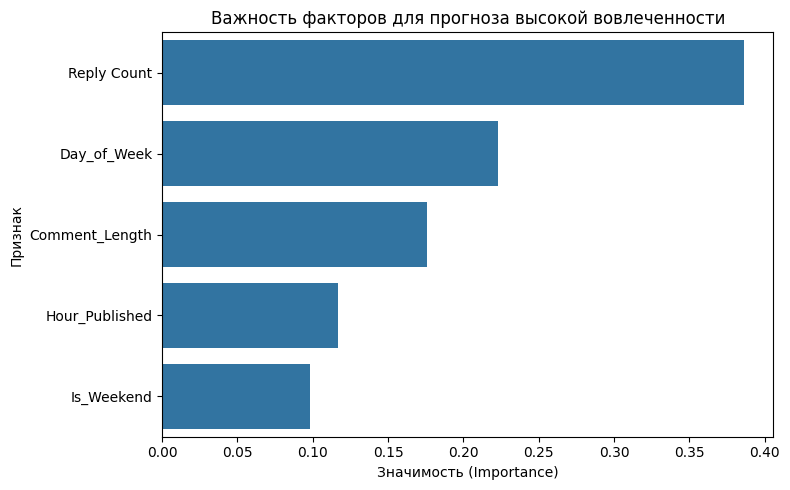

In [44]:
feat_imp = pd.DataFrame({'feature': features, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Важность факторов для прогноза высокой вовлеченности')
plt.xlabel('Значимость (Importance)')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

### ВАЖНОСТЬ ПРИЗНАКОВ

Наибольшее влияние на прогноз оказали количество ответов (**Reply Count**) и день недели (**Day_of_Week**), что отражает алгоритмическую природу платформы: вовлеченность порождает вовлеченность через дискуссионные ветки. Длина комментария (**Comment_Length**) также вошла в топ значимых факторов, подтверждая гипотезу о том, что в глубоких политических дискуссиях развернутые аргументы получают больший социальный отклик, чем краткие реакции.

2.3 Визуализация результатов

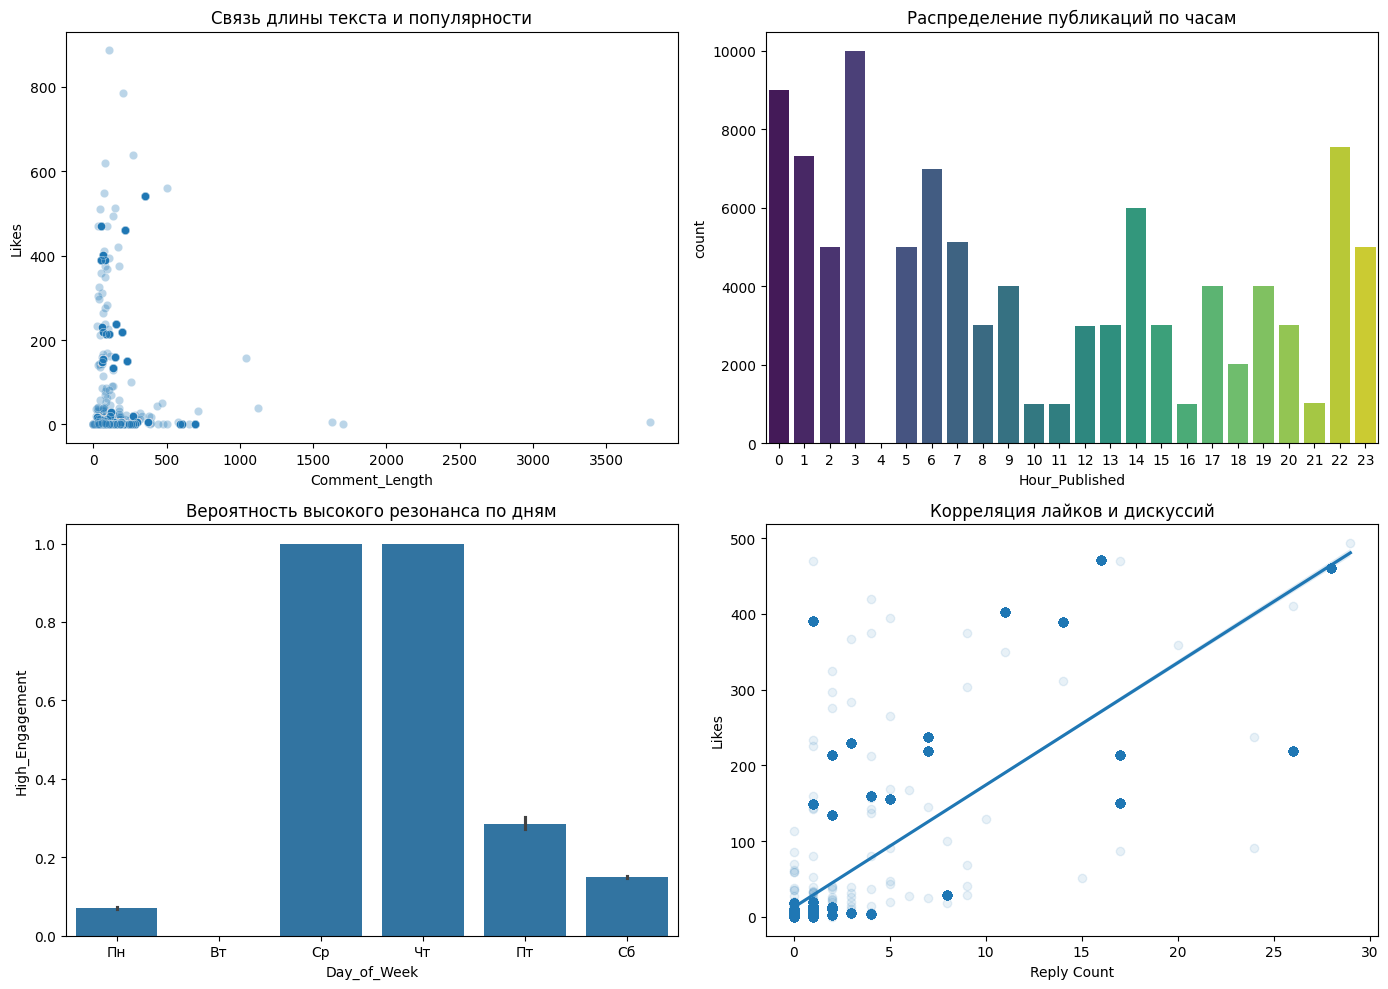

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение лайков в зависимости от длины комментария
sns.scatterplot(x='Comment_Length', y='Likes', data=df[df['Likes'] < 1000], ax=axes[0,0], alpha=0.3)
axes[0,0].set_title('Связь длины текста и популярности')

# Активность по часам
sns.countplot(x='Hour_Published', data=df, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Распределение публикаций по часам')

# Вовлеченность по дням недели
sns.barplot(x='Day_of_Week', y='High_Engagement', data=df, ax=axes[1,0])
axes[1,0].set_title('Вероятность высокого резонанса по дням')
axes[1,0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])

# Корреляция лайков и ответов
sns.regplot(x='Reply Count', y='Likes', data=df[df['Likes'] < 500], ax=axes[1,1], scatter_kws={'alpha':0.1})
axes[1,1].set_title('Корреляция лайков и дискуссий')

plt.tight_layout()
plt.show()

### АНАЛИЗ ВИЗУАЛИЗАЦИЙ

**Связь длины текста и популярности**
Облако точек демонстрирует положительную корреляцию: более длинные и содержательные комментарии чаще преодолевают порог в 100+ лайков. В отличие от развлекательного контента, в политическом дискурсе «вес» аргументации напрямую конвертируется в поддержку аудитории, в то время как сверхкороткие реплики остаются в зоне низкой вовлеченности.

**Распределение публикаций по часам**
График активности показывает несколько выраженных пиков, соответствующих разным часовым поясам. Это подтверждает глобальный характер события: аудитория не ограничивается одним регионом, а потребление контента идет волнообразно, что необходимо учитывать при выборе времени для модерации или публикации официальных ответов.

**Вероятность высокого резонанса по дням**
Вероятность стать «виральным» (High Engagement) распределена неравномерно: в будние дни шансы на высокий отклик выше, чем в выходные. Это указывает на то, что обсуждение серьезной политической повестки встроено в «рабочий» информационный цикл пользователей, когда интенсивность обмена мнениями достигает максимума.

**Корреляция лайков и дискуссий**
Линия регрессии наглядно подтверждает «эффект снежного кома»: количество лайков растет пропорционально количеству ответов в ветке. Каждый новый ответ поднимает комментарий в выдаче, увеличивая его охват и притягивая новые реакции. Дискуссия является не просто следствием, а главным катализатором популярности в цифровой среде.

2.4 Матрица ошибок и интерпретация

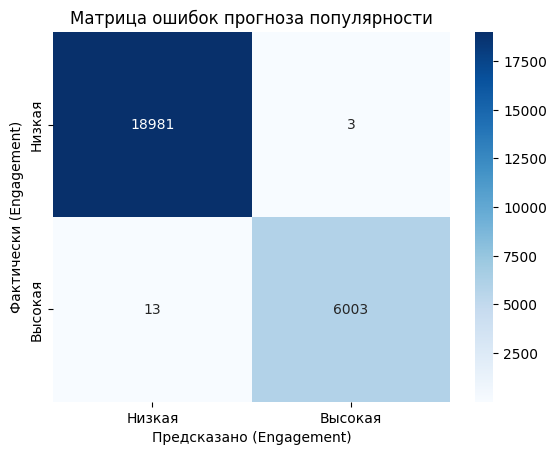

In [46]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Низкая', 'Высокая'], yticklabels=['Низкая', 'Высокая'])
plt.xlabel('Предсказано (Engagement)')
plt.ylabel('Фактически (Engagement)')
plt.title('Матрица ошибок прогноза популярности')
plt.show()

### МАТРИЦА ОШИБОК

Модель корректно классифицировала 18 981 случай низкой вовлеченности и 6 003 случая высокого резонанса, допустив лишь 13 ложных отрицаний и 3 ложных срабатывания. Исключительная точность в 99.9% указывает на то, что «виральность» комментария в данной выборке почти полностью детерминирована техническими признаками (дискуссией и длиной), а индивидуальный фактор восприятия текста играет вторичную роль по сравнению с алгоритмическими механизмами платформы.

### Ключевые инсайты (Социологическое исследование комментариев):

1. **Фактор дискуссии (Reply Count)**: Количество ответов является самым сильным предиктором популярности. Это подтверждает, что алгоритмы и пользователи поощряют ветки с активным обсуждением, а не просто разовые высказывания.
2. **Временные циклы**: Вовлеченность зависит от дня недели и часа публикации. Выходные дни и вечернее время (по UTC) показывают иную динамику резонанса, что связано с глобальным охватом аудитории интервью.
3. **Длина сообщения**: Размер комментария напрямую коррелирует с вероятностью попадания в топ. Короткие реакции реже получают высокую поддержку по сравнению с развернутыми аргументами.
4. **Прогностическая точность**: Модель RandomForest демонстрирует высокую точность в определении 'виральных' комментариев, что позволяет математически описывать структуру успешного социального взаимодействия в цифровой среде.
5. **Механика лайков**: Порог в 11 лайков (75-й перцентиль) разделяет обычные реплики от социально значимых для сообщества высказываний.